In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


#Import the dataset
url = 'https://raw.githubusercontent.com/Bhumir2503/Cosc325_Stock_Predictor/refs/heads/main/berkshire_hathaway_data.csv?token=GHSAT0AAAAAACYYKBB5BTZZH2H6NGALHVR4ZYIFZVQ'
dataset = pd.read_csv(url)

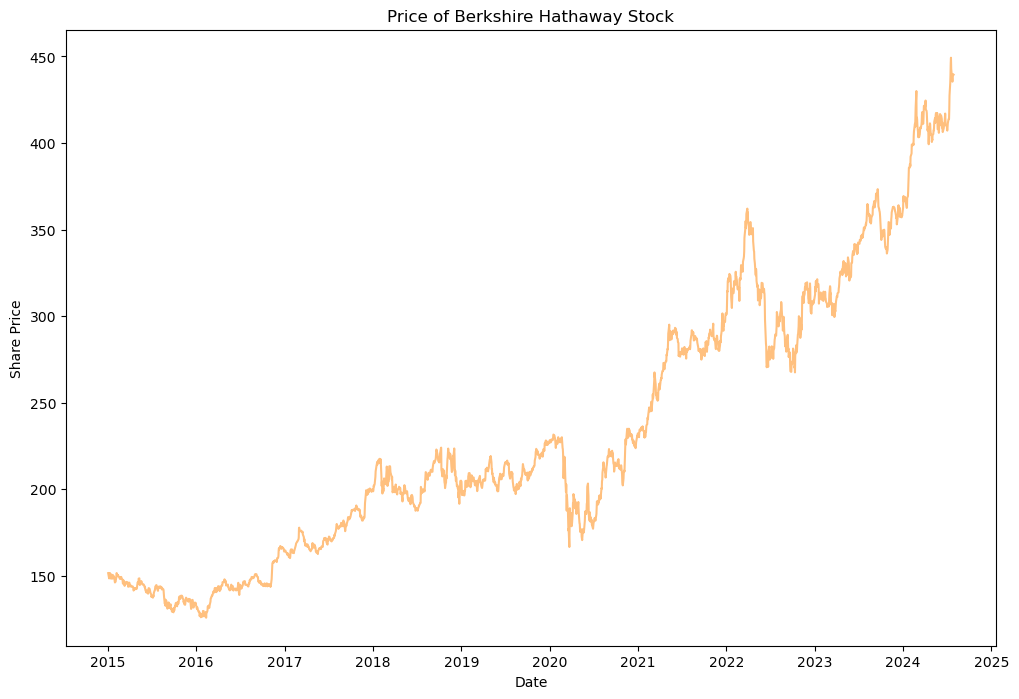

In [21]:
#Drop rows with missing values and convert date to datetime format
clean_df = dataset.dropna()
clean_df['Date'] = pd.to_datetime(clean_df['Date'])

#Simple plot to visualize the stock price
plt.figure(figsize=(12, 8))
plt.plot(clean_df['Date'], clean_df['High'], color='#ff8200', alpha=0.5)
plt.title('Price of Berkshire Hathaway Stock')
plt.xlabel('Date')
plt.ylabel('Share Price')
plt.show()

In [134]:
#Select the following columns to be features and select all rows except very last row
x = clean_df[['Open', 'Low', 'Close', 'Adj Close', 'Volume']].head(-1)
x = x.values

#Select 'High' price to be target value. Select all but first row. 
y = clean_df[['High']].tail(-1)
y = y.values

#The goal here is to have all features (x vector) used to make predictions on the following day's high price (y vector)
print('Shape of feature vector: ', x.shape)
print('Shape of target vector:', y.shape)

Shape of feature vector:  (2407, 5)
Shape of target vector: (2407, 1)


In [146]:
#Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

#Initialize linear model and fit training data to model
model = LinearRegression()
model.fit(x_train, y_train)

#Printing R2 score for training data. Very high score (close to 1) indicates model explains significant amount of data
#variability, indicating a good fit
print('Training data R2 Score:', model.score(x_train, y_train))

Training data R2 Score 0.9993313549904053


In [148]:
#Make predictions on testing data
predicted_high_prices = model.predict(x_test)

#Print R2 Score comparing predicted vs actual prices. Very high score (close to 1) indicates predictions were very accurate 
print('Testing data R2 Score:', r2_score(y_test, predicted_high_prices))

Testing data R2 Score: 0.9991274687667783


In [154]:
#Compare actual vs predicted prices
comparison = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': predicted_high_prices.flatten()})
print(comparison)

         Actual   Predicted
0    363.390015  362.522597
1    230.000000  233.191399
2    179.720001  179.848990
3    270.709991  271.838450
4    208.479996  208.090817
..          ...         ...
477  184.240005  187.991508
478  289.399994  288.888016
479  294.000000  290.414419
480  142.000000  142.889541
481  220.000000  220.877096

[482 rows x 2 columns]
